In [14]:
import pandas as pd

data = pd.read_csv('../Dataset/customer_praktikum.csv')

data.head(5)

,customer_id,age,monthly_income,account_balance,city,education_level,has_credit_card,last_login_days,churn
0,1,80.0,5342000.0,18784900.0,Bandung,S2,Yes,NaN,1
1,2,82.0,5880000.0,10389200.0,Surabaya,SMA,Yes,NaN,0
2,3,79.0,8495000.0,19348000.0,Surabaya,S2,No,NaN,1
3,4,85.0,8221000.0,21778200.0,Jakarta,D3,Yes,NaN,0
4,5,90.0,6958000.0,17067200.0,Bandung,S1,Yes,NaN,0


In [15]:
data.isna().sum()

customer_id          0
age                 15
monthly_income      15
account_balance     15
city                15
education_level     15
has_credit_card     15
last_login_days    200
churn                0
dtype: int64

memisahkan kolom

In [16]:
# print(data.info())
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

cat_cols = data.select_dtypes(include=['string', 'object']).columns
print(cat_cols)

Index(['customer_id', 'age', 'monthly_income', 'account_balance',
       'last_login_days', 'churn'],
      dtype='str')
Index(['city', 'education_level', 'has_credit_card'], dtype='str')


## mengisi value kosong pada kolom numerik dengan mean


In [17]:
for col in num_cols:
    mean_value = data[col].mean()
    data[col] = data[col].fillna(mean_value)

    print(f"Mean kolom '{col}' telah diisi: {mean_value}")

data.head(5)


Mean kolom 'customer_id' telah diisi: 150.5
Mean kolom 'age' telah diisi: 35.73263157894736
Mean kolom 'monthly_income' telah diisi: 7581621.052631579
Mean kolom 'account_balance' telah diisi: 15439183.50877193
Mean kolom 'last_login_days' telah diisi: 32.39
Mean kolom 'churn' telah diisi: 0.56


,customer_id,age,monthly_income,account_balance,city,education_level,has_credit_card,last_login_days,churn
0,1,80.0,5342000.0,18784900.0,Bandung,S2,Yes,32.39,1
1,2,82.0,5880000.0,10389200.0,Surabaya,SMA,Yes,32.39,0
2,3,79.0,8495000.0,19348000.0,Surabaya,S2,No,32.39,1
3,4,85.0,8221000.0,21778200.0,Jakarta,D3,Yes,32.39,0
4,5,90.0,6958000.0,17067200.0,Bandung,S1,Yes,32.39,0


In [19]:
for col in num_cols:
    median_value = data[col].median()
    data[col] = data[col].fillna(median_value)
    print(f"Median kolom '{col}' telah diisi: {median_value}")

data.head(5)


Median kolom 'customer_id' telah diisi: 150.5
Median kolom 'age' telah diisi: 35.73263157894736
Median kolom 'monthly_income' telah diisi: 7096000.0
Median kolom 'account_balance' telah diisi: 15439183.50877193
Median kolom 'last_login_days' telah diisi: 32.39
Median kolom 'churn' telah diisi: 1.0


,customer_id,age,monthly_income,account_balance,city,education_level,has_credit_card,last_login_days,churn
0,1,80.0,5342000.0,18784900.0,Bandung,S2,Yes,32.39,1
1,2,82.0,5880000.0,10389200.0,Surabaya,SMA,Yes,32.39,0
2,3,79.0,8495000.0,19348000.0,Surabaya,S2,No,32.39,1
3,4,85.0,8221000.0,21778200.0,Jakarta,D3,Yes,32.39,0
4,5,90.0,6958000.0,17067200.0,Bandung,S1,Yes,32.39,0


In [22]:
for col in cat_cols:
    mode_value = data[col].mode()[0]
    data[col] = data[col].fillna(mode_value)
    print(f"Mode kolom '{col}' telah diisi: {mode_value}")

Mode kolom 'city' telah diisi: Bandung
Mode kolom 'education_level' telah diisi: S1
Mode kolom 'has_credit_card' telah diisi: Yes


In [23]:
## cek ulang mising value
data.isna().sum()

customer_id        0
age                0
monthly_income     0
account_balance    0
city               0
education_level    0
has_credit_card    0
last_login_days    0
churn              0
dtype: int64

In [24]:
## simpan dataset yang bersih

In [25]:
data.to_csv('../Dataset/Costumer_Praktikum_clean.csv', index=False)

### OUtlier detection & tratement

In [ ]:
#data terbaru
import numpy as np

dt = pd.read_csv('../Dataset/Costumer_Praktikum_clean.csv')
dt.head(2)

,customer_id,age,monthly_income,account_balance,city,education_level,has_credit_card,last_login_days,churn
0,1,80.000000,5.342000e+06,1.878490e+07,Bandung,S2,Yes,32.39,1
1,2,82.000000,5.880000e+06,1.038920e+07,Surabaya,SMA,Yes,32.39,0
2,3,79.000000,8.495000e+06,1.934800e+07,Surabaya,S2,No,32.39,1
3,4,85.000000,8.221000e+06,2.177820e+07,Jakarta,D3,Yes,32.39,0
4,5,90.000000,6.958000e+06,1.706720e+07,Bandung,S1,Yes,32.39,0
5,6,32.700000,5.000000e+07,2.438400e+07,Bandung,S1,Yes,32.39,1
6,7,50.800000,6.500000e+07,1.113110e+07,Jakarta,S1,Yes,32.39,0
7,8,42.700000,8.000000e+07,8.776700e+06,Yogyakarta,S1,No,32.39,0
8,9,30.300000,8.094000e+06,6.106400e+06,Jakarta,S1,No,32.39,0
9,10,35.732632,7.581621e+06,1.543918e+07,Bandung,D3,No,26.80,0


In [31]:
## memisahkan kolom 

num_cols = dt.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['customer_id', 'age', 'monthly_income', 'account_balance',
       'last_login_days', 'churn'],
      dtype='str')


### metode iqr InterQuatile Range

In [32]:
#menghoitung iqr dan batas outline 

# menguku rentang 50%  datang tengah, yaitu selesih antara kuartil 3 dan kuartil 1

#fungsi untuk menghjitung batas bawah dan atas outlier

def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

## menguitybf bersama outloiner setiap koolom numerik

In [34]:
for coll in num_cols:
    lb, ub = iqr_bounds(dt[coll].dropna())
    print(f" '{coll}'-> lower: {lb}, uppr: {ub}")

 'customer_id'-> lower: -148.5, uppr: 449.5
 'age'-> lower: 9.225000000000009, uppr: 60.624999999999986
 'monthly_income'-> lower: 1851500.0, uppr: 12089500.0
 'account_balance'-> lower: 2893625.0, uppr: 27747625.0
 'last_login_days'-> lower: 32.39, uppr: 32.39
 'churn'-> lower: -1.5, uppr: 2.5


In [ ]:
data_outlier = pd.DataFrame(index=dt.index)

for col in num_cols:
    lb, ub = iqr_bounds(dt[col].dropna())
    data_outlier[col] = (dt[col]<lb) | (dt[col]>ub)

print(data_outlier.sum())

customer_id          0
age                  9
monthly_income       4
account_balance      5
last_login_days    100
churn                0
dtype: int64


In [43]:
# treatment penanganan masalah outlier

data_clean = dt.copy()

# print(data_clean[num_cols].describe())

for col in num_cols:
    lb, ub = iqr_bounds(data_clean[col].dropna())
    data_clean[col] = np.where(data_clean[col]<lb, lb, data_clean[col])
    data_clean[col] = np.where(data_clean[col]>ub, ub, data_clean[col])

print(data_clean[num_cols].describe())
    

       customer_id         age  monthly_income  account_balance  \
count   300.000000  300.000000    3.000000e+02     3.000000e+02   
mean    150.500000   35.331715    7.048954e+06     1.544565e+07   
std      86.746758    9.989432    1.961104e+06     4.867055e+06   
min       1.000000    9.225000    2.057000e+06     2.893625e+06   
25%      75.750000   28.500000    5.690750e+06     1.221388e+07   
50%     150.500000   35.732632    7.096000e+06     1.543918e+07   
75%     225.250000   41.350000    8.250250e+06     1.842738e+07   
max     300.000000   60.625000    1.208950e+07     2.774762e+07   

       last_login_days       churn  
count     3.000000e+02  300.000000  
mean      3.239000e+01    0.560000  
std       1.423460e-14    0.497216  
min       3.239000e+01    0.000000  
25%       3.239000e+01    0.000000  
50%       3.239000e+01    1.000000  
75%       3.239000e+01    1.000000  
max       3.239000e+01    1.000000  


Text(0.5, 1.0, 'data belum clean')

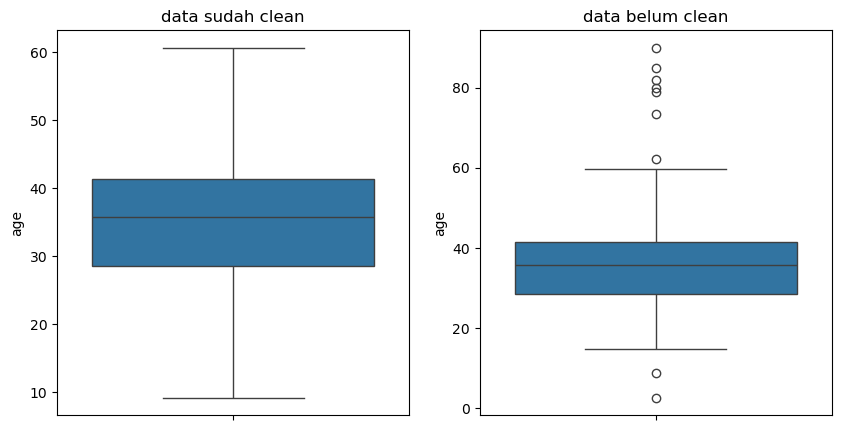

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

#visualiasi data

col = 'age'

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(y=data_clean[col])
plt.title(f"data sudah clean")


plt.subplot(1,2,2)
sns.boxplot(y=dt[col])
plt.title(f"data belum clean")
